In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from PIL import Image
from pathlib import Path
from collections import Counter
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Part 3 — Deep FCNN: Gradient Flow and Training Robustness

## 1. Dataset and Preprocessing

This experiment uses a 10-class subset of Tiny ImageNet.

Each image is an RGB `64 × 64` image. The images are converted to tensors using `ToTensor()`, which scales the pixel values to the `[0, 1]` range.

Only the first 10 classes listed in `wnids.txt` are selected. Each selected class contributes 500 training images, giving a balanced training set of 5,000 images.

The images are later flattened into 12,288-dimensional vectors because the model is fully connected rather than convolutional.

In [12]:
data_dir = Path("../Data/TinyImageNet/tiny-imagenet-200")

train_dir = data_dir / "train"
val_dir = data_dir / "val"

print(data_dir)
print(train_dir.exists())
print(val_dir.exists())

..\Data\TinyImageNet\tiny-imagenet-200
True
True


In [13]:
with open(data_dir / "wnids.txt", "r") as f:
    class_ids = [line.strip() for line in f]

print("Number of classes:", len(class_ids))
print(class_ids[:10])

Number of classes: 200
['n02124075', 'n04067472', 'n04540053', 'n04099969', 'n07749582', 'n01641577', 'n02802426', 'n09246464', 'n07920052', 'n03970156']


In [14]:
selected_classes = class_ids[:10]

print("Selected classes:")
for i, class_id in enumerate(selected_classes):
    print(i, class_id)

Selected classes:
0 n02124075
1 n04067472
2 n04540053
3 n04099969
4 n07749582
5 n01641577
6 n02802426
7 n09246464
8 n07920052
9 n03970156


In [15]:
class_to_label = {
    class_id: label
    for label, class_id in enumerate(selected_classes)
}

print(class_to_label)

{'n02124075': 0, 'n04067472': 1, 'n04540053': 2, 'n04099969': 3, 'n07749582': 4, 'n01641577': 5, 'n02802426': 6, 'n09246464': 7, 'n07920052': 8, 'n03970156': 9}


In [16]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [17]:
class TinyImageNet10(Dataset):

    def __init__(self, root_dir, selected_classes, class_to_label, transform=None):
        self.root_dir = Path(root_dir)
        self.selected_classes = selected_classes
        self.class_to_label = class_to_label
        self.transform = transform

        self.samples = []

        for class_id in selected_classes:
            image_dir = self.root_dir / class_id / "images"

            for image_path in image_dir.glob("*.JPEG"):
                self.samples.append(
                    (image_path, class_to_label[class_id])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
train_dataset = TinyImageNet10(
    root_dir=train_dir,
    selected_classes=selected_classes,
    class_to_label=class_to_label,
    transform=transform
)

print("Training samples:", len(train_dataset))

Training samples: 5000


In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

In [20]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([128, 3, 64, 64])
Labels shape: torch.Size([128])
Labels: tensor([9, 3, 6, 8, 4, 5, 4, 0, 4, 5])


### Input Representation

A batch has shape `(batch_size, 3, 64, 64)`. Before entering the FCNN, each image is flattened into a vector of 12,288 features.

This preserves all pixel values but removes the explicit two-dimensional structure from the model's input representation.

In [21]:
images_flat = images.view(images.size(0), -1)

print("Flattened shape:", images_flat.shape)

Flattened shape: torch.Size([128, 12288])


In [22]:
input_size = 64 * 64 * 3

print(input_size)

12288


In [23]:
class_counts = Counter()

for _, label in train_dataset.samples:
    class_counts[label] += 1

for label in range(10):
    print(
        f"Class {label}: "
        f"{selected_classes[label]} → "
        f"{class_counts[label]} images"
    )

Class 0: n02124075 → 500 images
Class 1: n04067472 → 500 images
Class 2: n04540053 → 500 images
Class 3: n04099969 → 500 images
Class 4: n07749582 → 500 images
Class 5: n01641577 → 500 images
Class 6: n02802426 → 500 images
Class 7: n09246464 → 500 images
Class 8: n07920052 → 500 images
Class 9: n03970156 → 500 images


## 3. Deep FCNN Architecture

The input images are RGB images of size `64 × 64`, giving:

`64 × 64 × 3 = 12,288` input features after flattening.

The network uses eight hidden layers:

`12,288 → 1,024 → 512 → 256 → 128 → 128 → 64 → 64 → 32 → 10`

The deliberately deep fully connected architecture is used to make gradient-flow and optimization behavior more visible.

Two variants are implemented:

- **Deep Sigmoid:** Sigmoid activation after every hidden linear layer.
- **ReLU + BatchNorm:** Batch Normalization followed by ReLU after every hidden linear layer.

The output layer produces 10 logits for the ten-class classification task.

In [24]:
class DeepFCNN_Sigmoid(nn.Module):
    def __init__(self, input_size=12288, num_classes=10):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 128)
        self.fc6 = nn.Linear(128, 64)
        self.fc7 = nn.Linear(64, 64)
        self.fc8 = nn.Linear(64, 32)

        self.output = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        x = torch.sigmoid(self.fc5(x))
        x = torch.sigmoid(self.fc6(x))
        x = torch.sigmoid(self.fc7(x))
        x = torch.sigmoid(self.fc8(x))

        x = self.output(x)

        return x

## 5. Experiment 3.2 — Training Ablation Study

The second experiment investigates which training choices have the largest effect on the deep FCNN's validation performance.

The baseline configuration uses:

- ReLU + BatchNorm
- Dropout `p = 0.2`
- Adam optimizer
- Learning rate `0.001`
- 5 training epochs

Each ablation starts from a fresh model and changes one factor while keeping the other main settings fixed.

The goal is to measure sensitivity to regularization, learning rate, and optimizer choice under the same limited five-epoch training budget.

In [25]:
class DeepFCNN_ReLU_BN(nn.Module):
    def __init__(self, input_size=12288, num_classes=10):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)

        self.fc5 = nn.Linear(128, 128)
        self.bn5 = nn.BatchNorm1d(128)

        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)

        self.fc7 = nn.Linear(64, 64)
        self.bn7 = nn.BatchNorm1d(64)

        self.fc8 = nn.Linear(64, 32)
        self.bn8 = nn.BatchNorm1d(32)

        self.output = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = torch.relu(self.bn4(self.fc4(x)))
        x = torch.relu(self.bn5(self.fc5(x)))
        x = torch.relu(self.bn6(self.fc6(x)))
        x = torch.relu(self.bn7(self.fc7(x)))
        x = torch.relu(self.bn8(self.fc8(x)))

        x = self.output(x)

        return x

In [26]:
sigmoid_model = DeepFCNN_Sigmoid()

relu_bn_model = DeepFCNN_ReLU_BN()

In [27]:
print("SIGMOID MODEL")
print(sigmoid_model)

print("\nRELU + BATCHNORM MODEL")
print(relu_bn_model)

SIGMOID MODEL
DeepFCNN_Sigmoid(
  (fc1): Linear(in_features=12288, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=128, bias=True)
  (fc6): Linear(in_features=128, out_features=64, bias=True)
  (fc7): Linear(in_features=64, out_features=64, bias=True)
  (fc8): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)

RELU + BATCHNORM MODEL
DeepFCNN_ReLU_BN(
  (fc1): Linear(in_features=12288, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=256, bias=T

In [28]:
sigmoid_linear_layers = [
    module for module in sigmoid_model.modules()
    if isinstance(module, nn.Linear)
]

relu_bn_linear_layers = [
    module for module in relu_bn_model.modules()
    if isinstance(module, nn.Linear)
]

print("Sigmoid Linear layers:", len(sigmoid_linear_layers))
print("ReLU + BN Linear layers:", len(relu_bn_linear_layers))

Sigmoid Linear layers: 9
ReLU + BN Linear layers: 9


In [29]:
print(sigmoid_model.fc1.weight.shape)
print(relu_bn_model.fc1.weight.shape)

torch.Size([1024, 12288])
torch.Size([1024, 12288])


## 4. Experiment 3.1 — Vanishing Gradients

The first experiment investigates gradient flow in a deep FCNN by comparing two activation/normalization strategies:

1. **Sigmoid activations** throughout the hidden layers.
2. **ReLU + Batch Normalization** throughout the hidden layers.

Both models use the same architecture, training data, optimizer, learning rate, and five-epoch training budget.

For each epoch, the L2 norm of the gradient of the first fully connected layer (`fc1.weight`) is averaged across training batches. This provides a direct measurement of how much gradient reaches the earliest layer of the network.

The experiment also tracks training loss to determine whether the observed gradient behavior is associated with effective optimization.

In [33]:
def train_with_gradient_tracking(model, train_loader, epochs=5, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    epoch_losses = []
    gradient_norms = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        first_layer_gradient_sum = 0.0
        num_batches = 0

        for X_batch, y_batch in train_loader:

            # Flatten 3 × 64 × 64 → 12288
            X_batch = X_batch.view(X_batch.size(0), -1)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(X_batch)

            # Loss
            loss = criterion(outputs, y_batch)

            # Backpropagation
            loss.backward()

            # First-layer gradient norm
            gradient_norm = model.fc1.weight.grad.norm(2).item()

            first_layer_gradient_sum += gradient_norm
            num_batches += 1

            # Update parameters
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / num_batches
        average_gradient_norm = first_layer_gradient_sum / num_batches

        epoch_losses.append(average_loss)
        gradient_norms.append(average_gradient_norm)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {average_loss:.4f} "
            f"First-layer gradient norm: {average_gradient_norm:.6f}"
        )

    return epoch_losses, gradient_norms

In [34]:
sigmoid_model = DeepFCNN_Sigmoid()

In [35]:
sigmoid_losses, sigmoid_gradient_norms = train_with_gradient_tracking(
    sigmoid_model,
    train_loader,
    epochs=5,
    learning_rate=0.001
)

Epoch [1/5] Loss: 2.3134 First-layer gradient norm: 0.000000
Epoch [2/5] Loss: 2.3051 First-layer gradient norm: 0.000000
Epoch [3/5] Loss: 2.3047 First-layer gradient norm: 0.000000
Epoch [4/5] Loss: 2.3057 First-layer gradient norm: 0.000000
Epoch [5/5] Loss: 2.3054 First-layer gradient norm: 0.000000


In [36]:
relu_bn_model = DeepFCNN_ReLU_BN()

In [37]:
relu_bn_losses, relu_bn_gradient_norms = train_with_gradient_tracking(
    relu_bn_model,
    train_loader,
    epochs=5,
    learning_rate=0.001
)

Epoch [1/5] Loss: 2.1820 First-layer gradient norm: 1.138399
Epoch [2/5] Loss: 2.0341 First-layer gradient norm: 0.135368
Epoch [3/5] Loss: 1.9289 First-layer gradient norm: 0.196544
Epoch [4/5] Loss: 1.8237 First-layer gradient norm: 0.313582
Epoch [5/5] Loss: 1.7474 First-layer gradient norm: 0.301956


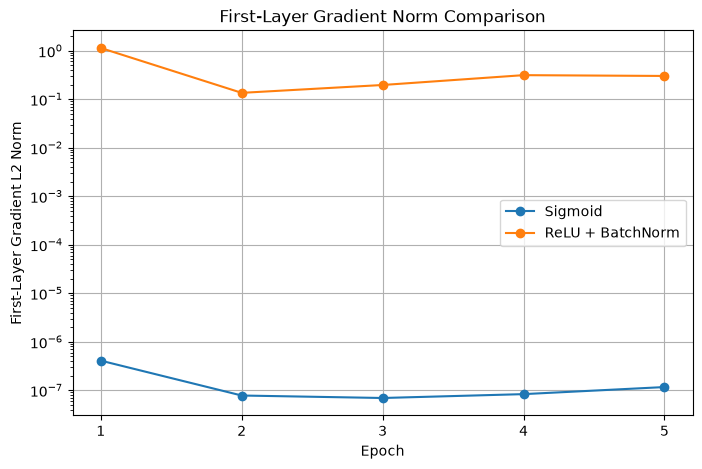

In [38]:
plt.figure(figsize=(8, 5))

epochs = range(1, 6)

plt.plot(
    epochs,
    sigmoid_gradient_norms,
    marker="o",
    label="Sigmoid"
)

plt.plot(
    epochs,
    relu_bn_gradient_norms,
    marker="o",
    label="ReLU + BatchNorm"
)

plt.xlabel("Epoch")
plt.ylabel("First-Layer Gradient L2 Norm")
plt.title("First-Layer Gradient Norm Comparison")
plt.xticks(list(epochs))
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

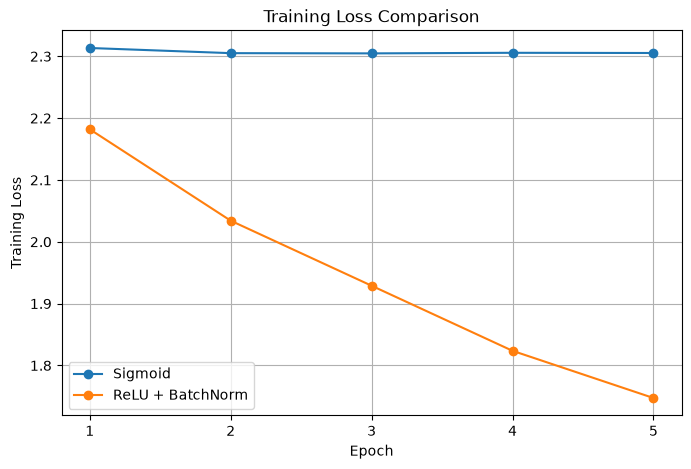

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    sigmoid_losses,
    marker="o",
    label="Sigmoid"
)

plt.plot(
    epochs,
    relu_bn_losses,
    marker="o",
    label="ReLU + BatchNorm"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

plt.show()

In [40]:
print("Epoch | Sigmoid Gradient | ReLU + BN Gradient")
print("-" * 50)

for epoch, (sig, relu) in enumerate(
    zip(sigmoid_gradient_norms, relu_bn_gradient_norms),
    start=1
):
    print(
        f"{epoch:5d} | "
        f"{sig:17.6f} | "
        f"{relu:19.6f}"
    )

Epoch | Sigmoid Gradient | ReLU + BN Gradient
--------------------------------------------------
    1 |          0.000000 |            1.138399
    2 |          0.000000 |            0.135368
    3 |          0.000000 |            0.196544
    4 |          0.000000 |            0.313582
    5 |          0.000000 |            0.301956


### Interpretation

The Sigmoid network produces extremely small first-layer gradients, remaining around `10⁻⁷` to `10⁻⁸` across the five epochs. Its training loss also remains close to `ln(10) ≈ 2.303`, the cross-entropy level associated with near-random predictions for ten classes.

The ReLU + BatchNorm network retains much larger first-layer gradients and reduces training loss from `2.1820` to `1.7474`.

This provides evidence that repeated Sigmoid activations create severe gradient attenuation in this deep network, while ReLU combined with Batch Normalization results in substantially healthier gradient flow and more effective optimization.

The experiment measures the gradient reaching the first layer specifically; it does not directly measure the gradient norm of every hidden layer.

In [41]:
print("Sigmoid gradient norms:")
for value in sigmoid_gradient_norms:
    print(f"{value:.12e}")

print("\nReLU + BatchNorm gradient norms:")
for value in relu_bn_gradient_norms:
    print(f"{value:.12e}")

Sigmoid gradient norms:
4.077901785138e-07
7.789797829005e-08
6.923963500327e-08
8.317721373885e-08
1.163529015358e-07

ReLU + BatchNorm gradient norms:
1.138399467617e+00
1.353675516322e-01
1.965442582965e-01
3.135822739452e-01
3.019556760788e-01


In [42]:
class DeepFCNN_ReLU_BN_Dropout(nn.Module):
    def __init__(
        self,
        input_size=12288,
        num_classes=10,
        dropout_rate=0.2
    ):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)

        self.fc5 = nn.Linear(128, 128)
        self.bn5 = nn.BatchNorm1d(128)

        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)

        self.fc7 = nn.Linear(64, 64)
        self.bn7 = nn.BatchNorm1d(64)

        self.fc8 = nn.Linear(64, 32)
        self.bn8 = nn.BatchNorm1d(32)

        self.dropout = nn.Dropout(dropout_rate)

        self.output = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn5(self.fc5(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn6(self.fc6(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn7(self.fc7(x)))
        x = self.dropout(x)

        x = torch.relu(self.bn8(self.fc8(x)))
        x = self.dropout(x)

        x = self.output(x)

        return x

In [43]:
def train_model(
    model,
    train_loader,
    epochs=5,
    learning_rate=0.001,
    optimizer_type="adam"
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_type == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    else:
        raise ValueError("optimizer_type must be 'adam' or 'sgd'")

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.view(X_batch.size(0), -1)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {average_loss:.4f}"
        )

In [44]:
def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.view(X_batch.size(0), -1)

            outputs = model(X_batch)

            predictions = torch.argmax(outputs, dim=1)

            total += y_batch.size(0)
            correct += (predictions == y_batch).sum().item()

    return 100 * correct / total

In [45]:
baseline_model = DeepFCNN_ReLU_BN_Dropout(
    dropout_rate=0.2
)

In [46]:
train_model(
    baseline_model,
    train_loader,
    epochs=5,
    learning_rate=0.001,
    optimizer_type="adam"
)

Epoch [1/5] Loss: 2.2956
Epoch [2/5] Loss: 2.1795
Epoch [3/5] Loss: 2.1020
Epoch [4/5] Loss: 2.0501
Epoch [5/5] Loss: 2.0139


## 6. Validation Set

The Tiny ImageNet validation images are stored together with their labels in `val_annotations.txt`.

A separate validation dataset is constructed for the same 10 selected classes. The resulting 500 images are used only for evaluating the trained models.

The validation set is not used during parameter updates.

In [47]:
val_dir = data_dir / "val"

print("Validation directory exists:", val_dir.exists())

for item in val_dir.iterdir():
    print(item)

Validation directory exists: True
..\Data\TinyImageNet\tiny-imagenet-200\val\images
..\Data\TinyImageNet\tiny-imagenet-200\val\val_annotations.txt


In [48]:
print((val_dir / "val_annotations.txt").exists())

True


In [49]:
class TinyImageNet10Val(Dataset):

    def __init__(
        self,
        val_dir,
        selected_classes,
        class_to_label,
        transform=None
    ):
        self.val_dir = Path(val_dir)
        self.selected_classes = selected_classes
        self.class_to_label = class_to_label
        self.transform = transform

        self.samples = []

        annotations_path = self.val_dir / "val_annotations.txt"

        with open(annotations_path, "r") as f:
            for line in f:
                parts = line.strip().split("\t")

                image_name = parts[0]
                class_id = parts[1]

                if class_id in selected_classes:
                    image_path = self.val_dir / "images" / image_name

                    self.samples.append(
                        (image_path, class_to_label[class_id])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [50]:
val_dataset = TinyImageNet10Val(
    val_dir=val_dir,
    selected_classes=selected_classes,
    class_to_label=class_to_label,
    transform=transform
)

print("Validation samples:", len(val_dataset))

Validation samples: 500


In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [ ]:
images, labels = next(iter(val_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([128, 3, 64, 64])
Labels: torch.Size([128])


In [ ]:
baseline_accuracy = evaluate_model(
    baseline_model,
    val_loader
)

print(f"Baseline accuracy: {baseline_accuracy:.2f}%")

Baseline accuracy: 29.20%


In [54]:
no_dropout_model = DeepFCNN_ReLU_BN()

In [55]:
train_model(
    no_dropout_model,
    train_loader,
    epochs=5,
    learning_rate=0.001,
    optimizer_type="adam"
)

Epoch [1/5] Loss: 2.1934
Epoch [2/5] Loss: 1.9742
Epoch [3/5] Loss: 1.8609
Epoch [4/5] Loss: 1.7675
Epoch [5/5] Loss: 1.6451


In [ ]:
no_dropout_accuracy = evaluate_model(
    no_dropout_model,
    val_loader
)

print(f"No Dropout accuracy: {no_dropout_accuracy:.2f}%")

No Dropout accuracy: 31.60%


In [57]:
lr_high_model = DeepFCNN_ReLU_BN_Dropout(
    dropout_rate=0.2
)

In [58]:
train_model(
    lr_high_model,
    train_loader,
    epochs=5,
    learning_rate=0.01,
    optimizer_type="adam"
)

Epoch [1/5] Loss: 2.2090
Epoch [2/5] Loss: 2.1191
Epoch [3/5] Loss: 2.0525
Epoch [4/5] Loss: 2.0286
Epoch [5/5] Loss: 2.0184


In [ ]:
lr_high_accuracy = evaluate_model(
    lr_high_model,
    val_loader
)

print(f"LR x10 accuracy: {lr_high_accuracy:.2f}%")

LR x10 accuracy: 28.20%


In [60]:
lr_low_model = DeepFCNN_ReLU_BN_Dropout(
    dropout_rate=0.2
)

In [61]:
train_model(
    lr_low_model,
    train_loader,
    epochs=5,
    learning_rate=0.0001,
    optimizer_type="adam"
)

Epoch [1/5] Loss: 2.3799
Epoch [2/5] Loss: 2.3509
Epoch [3/5] Loss: 2.3313
Epoch [4/5] Loss: 2.3121
Epoch [5/5] Loss: 2.2876


In [ ]:
lr_low_accuracy = evaluate_model(
    lr_low_model,
    val_loader
)

print(f"LR ÷10 accuracy: {lr_low_accuracy:.2f}%")

LR ÷10 accuracy: 18.60%


In [63]:
sgd_model = DeepFCNN_ReLU_BN_Dropout(
    dropout_rate=0.2
)

In [64]:
train_model(
    sgd_model,
    train_loader,
    epochs=5,
    learning_rate=0.001,
    optimizer_type="sgd"
)

Epoch [1/5] Loss: 2.3864
Epoch [2/5] Loss: 2.3736
Epoch [3/5] Loss: 2.3710
Epoch [4/5] Loss: 2.3598
Epoch [5/5] Loss: 2.3594


In [ ]:
sgd_accuracy = evaluate_model(
    sgd_model,
    val_loader
)

print(f"SGD accuracy: {sgd_accuracy:.2f}%")

SGD accuracy: 9.80%


In [66]:
results = {
    "Baseline": baseline_accuracy,
    "No Dropout": no_dropout_accuracy,
    "LR x10": lr_high_accuracy,
    "LR ÷10": lr_low_accuracy,
    "Adam → SGD": sgd_accuracy
}

for experiment, accuracy in results.items():
    print(f"{experiment:15s}: {accuracy:.2f}%")

Baseline       : 29.20%
No Dropout     : 31.60%
LR x10         : 28.20%
LR ÷10         : 18.60%
Adam → SGD     : 9.80%


## 7. Ablation Results and Interpretation

| Configuration | Validation Accuracy | Change vs Baseline |
|---|---:|---:|
| Baseline | 29.20% | 0.00 pp |
| No Dropout | 31.60% | +2.40 pp |
| Learning Rate ×10 | 28.20% | −1.00 pp |
| Learning Rate ÷10 | 18.60% | −10.60 pp |
| Adam → SGD | 9.80% | −19.40 pp |

### Interpretation

Removing Dropout produced the highest validation accuracy among the tested configurations, improving performance by 2.40 percentage points. Within this five-epoch training budget, the regularization introduced by Dropout did not appear beneficial.

Increasing the learning rate by 10× caused only a small decrease in validation accuracy, while reducing it by 10× caused a much larger decrease. This suggests that the smaller learning rate did not allow the model to optimize sufficiently within five epochs.

Replacing Adam with vanilla SGD produced the largest performance drop, from 29.20% to 9.80%. Among the factors tested, optimizer choice therefore had the strongest measured effect on final validation performance.

In [67]:
print("\nChange from baseline:")

for experiment, accuracy in results.items():
    difference = accuracy - baseline_accuracy

    print(
        f"{experiment:15s}: "
        f"{accuracy:.2f}% "
        f"({difference:+.2f} percentage points)"
    )


Change from baseline:
Baseline       : 29.20% (+0.00 percentage points)
No Dropout     : 31.60% (+2.40 percentage points)
LR x10         : 28.20% (-1.00 percentage points)
LR ÷10         : 18.60% (-10.60 percentage points)
Adam → SGD     : 9.80% (-19.40 percentage points)


In [68]:
ablation_table = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "No Dropout",
        "Learning Rate ×10",
        "Learning Rate ÷10",
        "Adam → SGD"
    ],
    "Accuracy (%)": [
        baseline_accuracy,
        no_dropout_accuracy,
        lr_high_accuracy,
        lr_low_accuracy,
        sgd_accuracy
    ],
    "Change vs Baseline (pp)": [
        0,
        no_dropout_accuracy - baseline_accuracy,
        lr_high_accuracy - baseline_accuracy,
        lr_low_accuracy - baseline_accuracy,
        sgd_accuracy - baseline_accuracy
    ]
})

ablation_table

,Experiment,Accuracy (%),Change vs Baseline (pp)
0,Baseline,29.2,0.0
1,No Dropout,31.6,2.4
2,Learning Rate ×10,28.2,-1.0
3,Learning Rate ÷10,18.6,-10.6
4,Adam → SGD,9.8,-19.4


## 8. Final Takeaways

This experiment exposes two different challenges that arise when a fully connected network becomes deep.

### Gradient flow

Repeated Sigmoid activations produced severe attenuation of the first-layer gradient, while ReLU combined with Batch Normalization maintained substantially larger gradients and continued reducing training loss.

### Training sensitivity

The ablation study showed that deep FCNN performance was sensitive to training choices. Under the five-epoch budget, optimizer choice had the largest measured effect, while reducing the learning rate substantially slowed useful optimization.

### Overall conclusion

The results show that increasing network depth alone is not sufficient. Activation functions, normalization, learning rate, optimizer choice, and regularization all influence whether a deep FCNN can train effectively.